In [9]:
from ast import literal_eval

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.utils import compute_model_accuracy, get_device, safetensors_metadata_parser
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
file_path = "/home/nsa325/work/nnscaling/model_saves/lotusroot_model.safetensors"

In [11]:
# Dataset config
metadata = safetensors_metadata_parser(file_path=file_path)
dataset_config = DatasetConfig(
    dataset_name=metadata["dataset"],
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [12]:
model = MLP.load_model(file_path, in_features=dataset.features.shape[-1]).eval()

{'config': '[10, 8, 6, 3]', 'dataset': 'SunflowerDataset', 'nonlinearity': 'relu', 'out_features': '2'}


Testing Accuracy: 0.987666666507721


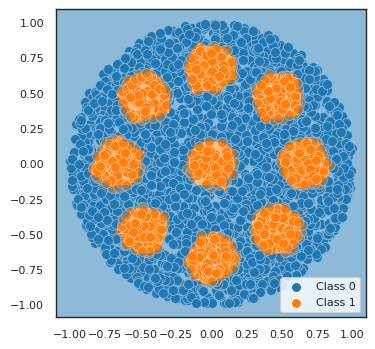

In [13]:
print(f"Testing Accuracy: {compute_model_accuracy(model.to('cpu'), dataset)}")

plot_decision_boundary(
    model,
    model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1, 2],
)

In [14]:
file_path = (
    "/home/nsa325/work/nnscaling/model_saves/scaling/loc_1_scaled_lotusroot_model.safetensors"
)
scaled_model = ScaledModel.load_model(model, file_path).eval()

/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:71: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(
/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:71: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(


Testing Accuracy: 0.5


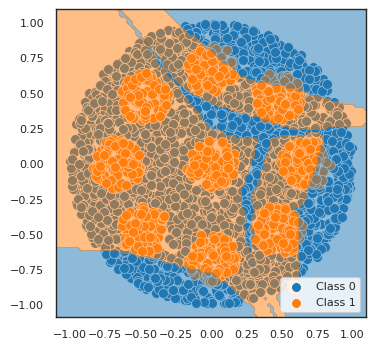

In [15]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

plot_decision_boundary(
    scaled_model,
    scaled_model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1, 2],
)

In [16]:
scaled_model

ScaledModel(
  (pre_inserts): Sequential(
    (0): LinearLayer(
      (linear): Linear(in_features=2, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
  )
  (scaled_layers): Sequential(
    (0): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (1): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (2): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (3): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (4): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (5): LinearLayer(
      (linear): Linear(in_features=10, out_features=10, bias=True)
      (activation_layer): ReLU()
    )
    (6): LinearLayer(
      